# 03 Competitive Benchmarking
### Imports and pulling data from the database

In [42]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
from pathlib import Path

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# PCA for visualization
from sklearn.decomposition import PCA

SRC_PATH = Path.cwd().parent / "src"
sys.path.append(str(SRC_PATH))

In [25]:
# Importing data from DB
conn = sqlite3.connect("../data/reviews_sample.db")

hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

tables = hotels_df['name'].tolist()

# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

We already have aggregated hotel data during the data preperation phase that is:
- grouped by hotel id
- on the same scale from 1 to 5

which means that the data is mostly ready for clustering for further analysis.

From [Siteminder hotel classifications](https://www.siteminder.com/r/hotel-classifications/), the main differences between the different star-hotels are services and room quality. Location and pricing also should factor into the equation.

Features used for clustering:
- avg_service_rating
- avg_value_rating
- avg location_rating
- avg_rooms_rating

Overall rating corresponds with the above features (except location rating) from EDA, so is likely a composite of other features and thus is not as useful. From a quick research scan, sleep quality rating, check in rating, and business service rating are not as key features in determining hotel type.

Tested **cleanliness rating** and does not seem to change the resultant analysis much. Seems correlative with **room rating**.

Also tested with and without **value rating** and does not seem to shift the analysis that much.

In [ ]:
FEATURES = ['avg_service_rating', 'avg_location_rating', 'avg_rooms_rating']
hotels = dataset['hotels'].dropna(subset=FEATURES).copy() #ensuring no NA values in the features of interest
print(f"{len(dataset['hotels']):,} hotels")

hotels.describe()

1,833 hotels


,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
count,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1833.000000,1829.000000,1833.000000,1488.000000,1462.000000
mean,240.115657,4.034437,4.132976,3.873015,3.880680,4.270316,3.975254,3.860633,3.945980,3.639811
std,261.328922,0.536785,0.590004,0.591733,0.487781,0.490899,0.541939,0.610048,0.678920,0.783138
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.833333,1.000000,1.000000,1.000000,1.000000
25%,67.000000,3.812000,3.894737,3.606061,3.629526,4.032389,3.731602,3.551724,3.600000,3.166667
50%,155.000000,4.129808,4.272727,3.964706,3.953704,4.364017,4.088050,3.975207,4.000000,3.736842
75%,316.000000,4.397727,4.538462,4.289538,4.214286,4.627692,4.352941,4.288991,4.421559,4.181818
max,1825.000000,5.000000,5.000000,5.000000,4.923077,5.000000,5.000000,5.000000,5.000000,5.000000


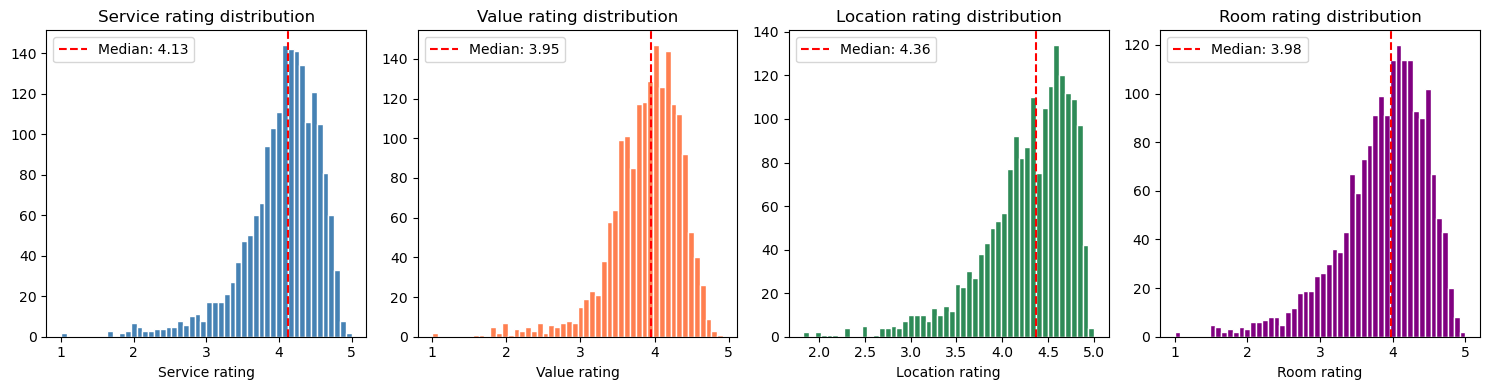

In [110]:
# Quick EDA visualizations to understand distributions of features
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Service Rating
axes[0].hist(hotels['avg_service_rating'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_xlabel('Service rating')
axes[0].set_title('Service rating distribution')
axes[0].axvline(hotels['avg_service_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_service_rating"].median():.2f}')
axes[0].legend()

# Value Rating
axes[1].hist(hotels['avg_value_rating'], bins=50, edgecolor='white', color='coral')
axes[1].set_xlabel('Value rating')
axes[1].set_title('Value rating distribution')
axes[1].axvline(hotels['avg_value_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_value_rating"].median():.2f}')
axes[1].legend()

# Location Rating
axes[2].hist(hotels['avg_location_rating'], bins=50, edgecolor='white', color='seagreen')
axes[2].set_xlabel('Location rating')
axes[2].set_title('Location rating distribution')
axes[2].axvline(hotels['avg_location_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_location_rating"].median():.2f}')
axes[2].legend()

# Rooms Rating
axes[3].hist(hotels['avg_rooms_rating'], bins=50, edgecolor='white', color='purple')
axes[3].set_xlabel('Room rating')
axes[3].set_title('Room rating distribution')
axes[3].axvline(hotels['avg_rooms_rating'].median(), color='red', linestyle='--', label=f'Median: {hotels["avg_rooms_rating"].median():.2f}')
axes[3].legend()

plt.tight_layout()
plt.show()

In [111]:
X = hotels[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures prepared and standardized")
print(f"   Shape: {X_scaled.shape}")
print(f"   Features: {FEATURES}")
print(f"\nBefore scaling (first row): {X[0].round(2)}")
print(f"After scaling (first row):  {X_scaled[0].round(2)}")


Features prepared and standardized
   Shape: (1833, 4)
   Features: ['avg_service_rating', 'avg_value_rating', 'avg_location_rating', 'avg_rooms_rating']

Before scaling (first row): [2.36 2.62 4.43 2.07]
After scaling (first row):  [-3.11 -2.59  0.33 -2.94]


In [112]:
# Finding Optimal k using Elbow + Silhouette

# Testing k-range from 2 to 10
k_range = range(2, 11)
inertias = []
silhouettes = []

print("Testing k values...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Append the inertia (within-cluster sum of squares) to the inertias list. 
    # Lower inertia = more compact clusters
    inertias.append(kmeans.inertia_)
    
    # Calculate the silhouette score, which measures how similar an object is to its own cluster compared to other clusters. 
    # Higher silhouette  = better defined clusters
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)

    print(f"  k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil:.3f}")

print(f"\nBest k by silhouette: {list(k_range)[np.argmax(silhouettes)]} (score: {max(silhouettes):.3f})")

Testing k values...
  k=2: Inertia=3,779, Silhouette=0.491
  k=3: Inertia=2,551, Silhouette=0.369
  k=4: Inertia=2,048, Silhouette=0.326
  k=5: Inertia=1,733, Silhouette=0.313
  k=6: Inertia=1,522, Silhouette=0.280
  k=7: Inertia=1,357, Silhouette=0.277
  k=8: Inertia=1,229, Silhouette=0.274
  k=9: Inertia=1,153, Silhouette=0.251
  k=10: Inertia=1,085, Silhouette=0.269

Best k by silhouette: 2 (score: 0.491)


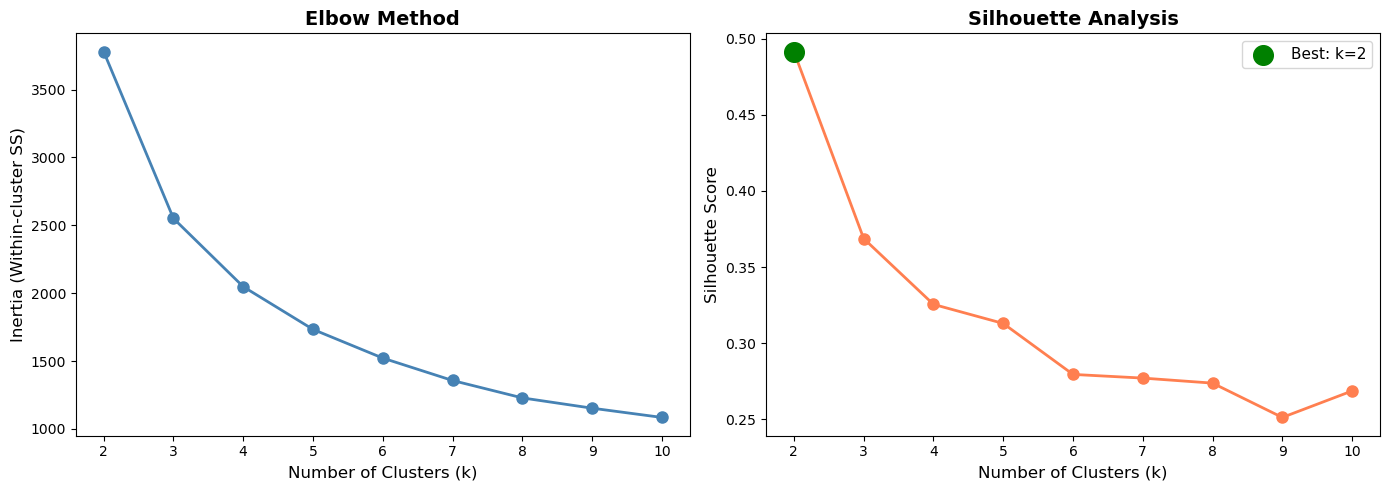

In [113]:
# Visualize Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster SS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, 'o-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))

# Highlight best k
best_k_idx = np.argmax(silhouettes)
axes[1].scatter([list(k_range)[best_k_idx]], [silhouettes[best_k_idx]],
                s=200, c='green', zorder=5, label=f'Best: k={list(k_range)[best_k_idx]}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Based on exploratory visualizations, choosing k with a value of 5. Enough segments for business to analyze, and still high enough silhouette score.

In [114]:
# Fit Final K-Means Model

CHOSEN_K = 5

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to data
hotels['kmeans_cluster'] = kmeans_labels

# Check cluster sizes
cluster_sizes = hotels['kmeans_cluster'].value_counts().sort_index()
print(f"K-Means Cluster Sizes (k={CHOSEN_K}):")
print("-" * 30)
for cluster, size in cluster_sizes.items():
    print(f"  Cluster {cluster}: {size:,} customers ({size/len(hotels)*100:.1f}%)")

print(f"\nSilhouette Score: {silhouette_score(X_scaled, kmeans_labels):.3f}")

K-Means Cluster Sizes (k=5):
------------------------------
  Cluster 0: 463 customers (25.3%)
  Cluster 1: 631 customers (34.4%)
  Cluster 2: 64 customers (3.5%)
  Cluster 3: 410 customers (22.4%)
  Cluster 4: 265 customers (14.5%)

Silhouette Score: 0.313


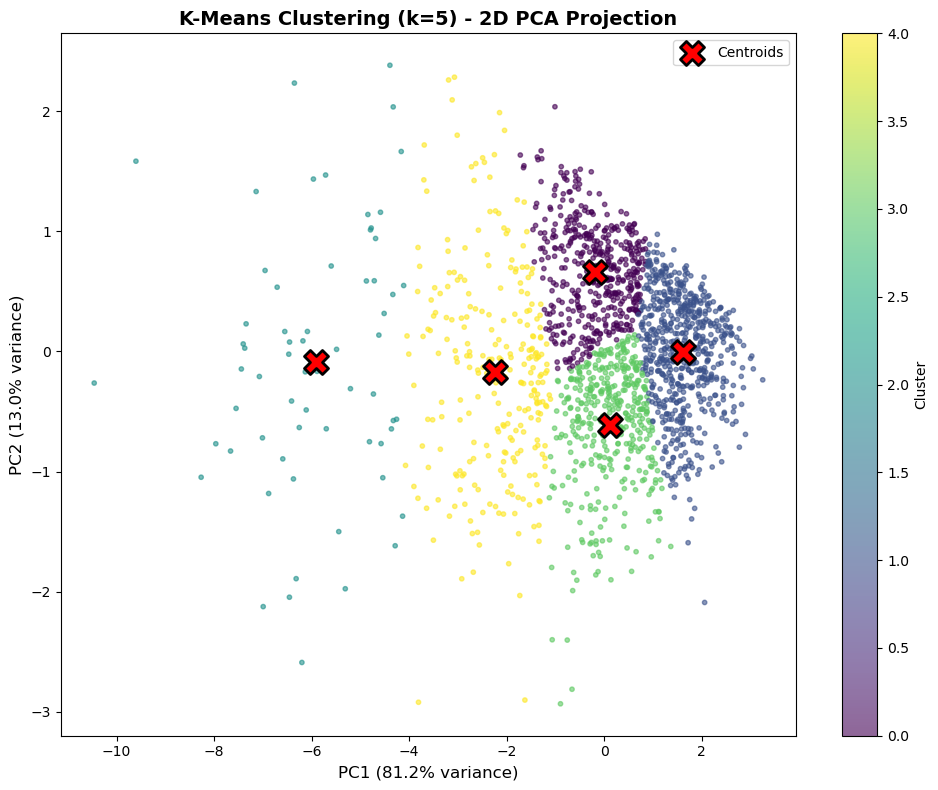

In [115]:
# Visualize clusters in 2D using PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot clusters
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap='viridis', alpha=0.6, s=10)

# Plot centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2,
           label='Centroids')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'K-Means Clustering (k={CHOSEN_K}) - 2D PCA Projection', fontsize=14, fontweight='bold')

plt.colorbar(scatter, label='Cluster')
ax.legend()
plt.tight_layout()
plt.show()

### Cluster profiling
Cluster profiling for business analysis

In [116]:
# Using K-Means clusters for profiling
profile = hotels.groupby('kmeans_cluster')[FEATURES].agg(['mean', 'median', 'std']).round(2)
print("Cluster Profiles (K-Means):")
display(profile)

Cluster Profiles (K-Means):


avg_service_rating              avg_value_rating               \
                             mean median   std             mean median   std   
kmeans_cluster                                                                 
0                            3.92   3.94  0.24             3.73   3.73  0.22   
1                            4.49   4.49  0.18             4.28   4.28  0.21   
2                            2.33   2.35  0.44             2.33   2.36  0.45   
3                            4.13   4.12  0.19             4.00   4.00  0.21   
4                            3.42   3.45  0.32             3.38   3.39  0.26   

               avg_location_rating              avg_rooms_rating               
                              mean median   std             mean median   std  
kmeans_cluster                                                                 
0                             4.52   4.55  0.20             3.70   3.72  0.30  
1                             4.60   4.62  0.21             4.39   4.40  0.24  
2                             3.01   3.00  0.59             2.10   2.13  0.43  
3                             4.02   4.06  0.26             3.99   4.00  0.24  
4                             3.73   3.75  0.40             3.12   3.14  0.35

In [118]:
# Compute Indexes (Relative to Average)

overall_means = hotels[FEATURES].mean()

# Calculate the mean of each feature for each individual cluster.
cluster_means = hotels.groupby('kmeans_cluster')[FEATURES].mean()

# Calculate the index for each cluster and feature.
# The index is (Cluster Mean / Overall Mean) * 100, rounded to the nearest integer.
index = (cluster_means / overall_means * 100).round(0).astype(int)

# Add the count of hotels in each cluster to the index DataFrame.
index['size'] = hotels.groupby('kmeans_cluster').size()

# Add the percentage of total hotels that each cluster represents.
index['pct'] = (index['size'] / len(hotels) * 100).round(1)

print("\n Cluster Index (100 = average):")
print("="*60)
display(index)


 Cluster Index (100 = average):


,avg_service_rating,avg_value_rating,avg_location_rating,avg_rooms_rating,size,pct
kmeans_cluster,,,,,,
0,97,96,106,96,463,25.3
1,111,110,108,114,631,34.4
2,58,60,71,54,64,3.5
3,102,103,94,103,410,22.4
4,85,87,87,81,265,14.5


### Break down per cluster

- **Convenient** (Cluster 0, 25.3% of hotels)
  - Slightly below average hotels that stand out because of their good location ratings. The opposite of cluster 3 (**good, but inconvenient** hotels)
  - Location is key for these hotels, and their marketing should emphasize this.
- **Top of the line** (Cluster 1, 34.4% of hotels)
  - These are the best hotels, with above average scores in every category.
- **Terrible** (Cluster 2, 3.35% of hotels)
  - These are the worst hotels, with especially low room and service ratings.
- **Good, but inconvenient** (Cluster 3, 22.4% of hotels)
  - Slightly above average hotels that are situated in more out of the way areas. The opposite of cluster 0 (**convenient** hotels)
  - These hotels are harder to get to, but are very good otherwise. Offering free transport options (hotel pick-up) can be a good way of enticing travellers to come here.
- **Below average** (Cluster 4, 14.5% of hotels)
  - Hotels that are below average in every rating, but not as bad as the terrible hotels.


In [120]:
print("\n SEGMENT STRATEGY TABLE")
print("="*80)
print()

strategy_template = """
| Cluster | Segment Name           | Key Profile            | Size  |
|---------|------------------------|------------------------|-------|
| 0       | Convenient             | Convenience is key     | 25.3% |
| 1       | Top of the line        | Best hotels            | 34.4% |
| 2       | Terrible               | Worst hotels           | 3.4%  |
| 3       | Good, but inconvenient | Good, but inconvenient | 22.4% |
| 4       | Below average          | Below average hotels   | 14.5% |

EXAMPLE STRATEGIES:
- Convenient → Emphasize convenience in marketing
- Top of the line → Continue to do what they are doing, referrals
- Terrible → Reorganization and especially improve room quality
- Good, but inconvenient → Offer free transport options to hotel
- Below average → Improve service and room quality first before tacking convenience factor
"""
print(strategy_template)


 SEGMENT STRATEGY TABLE


| Cluster | Segment Name           | Key Profile            | Size  |
|---------|------------------------|------------------------|-------|
| 0       | Convenient             | Convenience is key     | 25.3% |
| 1       | Top of the line        | Best hotels            | 34.4% |
| 2       | Terrible               | Worst hotels           | 3.4%  |
| 3       | Good, but inconvenient | Good, but inconvenient | 22.4% |
| 4       | Below average          | Below average hotels   | 14.5% |

EXAMPLE STRATEGIES:
- Convenient → Emphasize convenience in marketing
- Top of the line → Continue to do what they are doing, referrals
- Terrible → Reorganization and especially improve room quality
- Good, but inconvenient → Offer free transport options to hotel
- Below average → Improve service and room quality first before tacking convenience factor



In [6]:
conn.close()